In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
inventory_data = [
    {"id": 1, "name": "Arduino Kit", "category": "Hardware", "quantity": 5},
    {"id": 2, "name": "Figma License", "category": "Software", "quantity": 20},
    {"id": 3, "name": "USB Cable", "category": "Hardware", "quantity": 2},
    {"id": 4, "name": "Raspberry Pi", "category": "Hardware", "quantity": 0},
    {"id": 5, "name": "AWS Credits", "category": "Software", "quantity": 50}
]


In [3]:
df = pd.DataFrame(inventory_data)
total_items = df['quantity'].sum()
low_stock_threshold = 5
low_stock_items = df[df['quantity'] < low_stock_threshold]
category_counts = df.groupby('category')['quantity'].sum()
print(f"--- SYSTEM SUMMARY ---")
print(f"Total Physical/Digital Items in System: {total_items}")
print(f"Items requiring restock (Qty < 5): {len(low_stock_items)}")
print(f"\nLow Stock Details:\n{low_stock_items[['name', 'quantity']]}")


--- SYSTEM SUMMARY ---
Total Physical/Digital Items in System: 77
Items requiring restock (Qty < 5): 2

Low Stock Details:
           name  quantity
2     USB Cable         2
3  Raspberry Pi         0


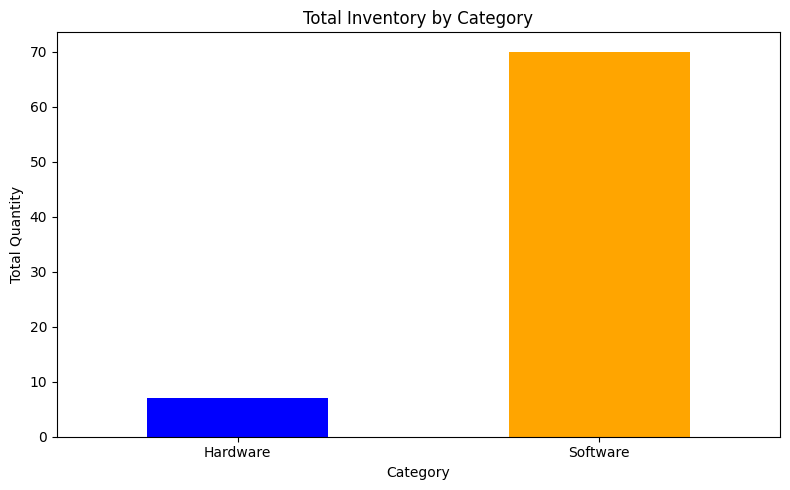

In [4]:
category_counts.plot(kind='bar', color=['blue', 'orange'], figsize=(8, 5))
plt.title('Total Inventory by Category')
plt.xlabel('Category')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
import json
import datetime

In [6]:
ml_predictions = [
    {"scene_id": "shelf_01", "name": "Arduino Kit", "confidence": 0.95},  # High confidence
    {"scene_id": "shelf_01", "name": "USB Cable", "confidence": 0.62},    # Low confidence
    {"scene_id": "shelf_02", "name": "Raspberry Pi", "confidence": 0.92}  # High confidence
]

db_inventory = {
    "Arduino Kit": 5,    # DB says in stock
    "USB Cable": 2,      # DB says in stock
    "Raspberry Pi": 0    # DB says out of stock!
}

In [7]:
CONF_THRESHOLD = 0.90

accepted_predictions = []
uncertain_predictions = []

for pred in ml_predictions:
    if pred["confidence"] >= CONF_THRESHOLD:
        accepted_predictions.append(pred)
    else:
        uncertain_predictions.append(pred)

print(f"Policy Output: {len(accepted_predictions)} Accepted, {len(uncertain_predictions)} Uncertain")

Policy Output: 2 Accepted, 1 Uncertain


In [9]:
audit_events = []
for pred in accepted_predictions:
    item_name = pred["name"]
    db_qty = db_inventory.get(item_name, 0)
    
    if db_qty > 0:
        event_type = "VERIFIED"
        action = "None needed - system matches reality."
    else:
        event_type = "DISCREPANCY"
        action = "Auto-update DB: Item found on shelf but marked out of stock."
        
    audit_events.append({
        "timestamp": datetime.datetime.now().isoformat(),
        "scene_id": pred["scene_id"],
        "item": item_name,
        "event_type": event_type,
        "confidence": pred["confidence"],
        "recommended_action": action
    })

In [10]:
for pred in uncertain_predictions:
    audit_events.append({
        "timestamp": datetime.datetime.now().isoformat(),
        "scene_id": pred["scene_id"],
        "item": pred["name"],
        "event_type": "UNCERTAIN",
        "confidence": pred["confidence"],
        "recommended_action": "Requires manual human review."
    })

with open("audit_log.jsonl", "w") as f:
    for event in audit_events:
        f.write(json.dumps(event) + "\n")

print("Audit log generated: audit_log.jsonl")

Audit log generated: audit_log.jsonl
